# All-Weather Analysis: ERA5 Reanalysis vs Kalshi Event Markets

This notebook pairs **ERA5 reanalysis weather data** (hourly temperature / precipitation) with **Kalshi event contract price histories** for the same city and date window. For each pair we plot the actual weather side-by-side with how the prediction market priced each outcome bucket in real time.

### Temperature Markets ("What will the high temperature be?")

| City | ERA5 File | Kalshi Market | Date |
|------|-----------|---------------|------|
| Austin | `AUS_TEMP_ERA.csv` | `kxhighaus-25jul26` | Jul 25–27, 2025 |
| Chicago | `CHI_TEMP_ERA.csv` | `kxhighchi-25jul26` | Jul 25–27, 2025 |
| Houston | `HOU_TEMP_ERA.csv` | `kxhighhou-25jul26` | Jul 25–27, 2025 |
| Los Angeles | `LA_TEMP_ERA.csv` | `kxhighlax-25dec15` | Dec 15–16, 2025 |
| Miami | `MIA_TEMP_ERA.csv` | `kxhighmia-25dec15` | Dec 15–16, 2025 |
| New York | `NY_TEMP_ERA.csv` | `kxhighny-25dec15` | Dec 15–16, 2025 |
| Philadelphia | `PHIL_TEMP_ERA.csv` | *(no Kalshi market)* | Jul 25–27, 2025 |

### Snow Markets (NYC, January 2026)

| Event | ERA5 File | Kalshi Market | Date |
|-------|-----------|---------------|------|
| NYC Monthly Snow | `NY_SNOW_ERA.csv` | `kxnycsnowm-26jan` | Jan 23–30, 2026 |
| NYC Snowstorm | `NY_SSNOW_ERA.csv` | `kxsnowstorm-26jannyc` | Jan 23–26, 2026 |

---
## Setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['font.size'] = 11

---
## Helper Functions

In [8]:
def load_era_temp(filepath):
    """Load an ERA5 temperature CSV (columns: time, temperature_f)."""
    df = pd.read_csv(filepath)
    df['time'] = pd.to_datetime(df['time'])
    return df


def load_era_snow(filepath):
    """Load an ERA5 snow/precipitation CSV (columns: time, precipitation_inches, temperature_c, is_snow)."""
    df = pd.read_csv(filepath)
    df['time'] = pd.to_datetime(df['time'])
    # Compute cumulative precipitation over the period
    df['cumulative_precip'] = df['precipitation_inches'].cumsum()
    # Cumulative snow only (where is_snow == True)
    df['snow_inches'] = df['precipitation_inches'].where(df['is_snow'], 0.0)
    df['cumulative_snow'] = df['snow_inches'].cumsum()
    return df


def load_kalshi(filepath):
    """Load a Kalshi price history CSV. Returns DataFrame with timestamp + all bucket columns."""
    df = pd.read_csv(filepath)
    df['timestamp'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None)
    # Convert cent prices to probabilities (0-1)
    bucket_cols = [c for c in df.columns if c != 'timestamp']
    for col in bucket_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce') / 100.0
    return df, bucket_cols


def _get_daily_highs(era_df):
    """Get daily high temperatures and their timestamps (compatible with all pandas versions)."""
    highs = {}
    high_times = {}
    for date, group in era_df.set_index('time')['temperature_f'].resample('D'):
        if len(group) > 0:
            highs[date] = group.max()
            high_times[date] = group.idxmax()
    return highs, high_times


def plot_temp_pair(era_df, kalshi_df, bucket_cols, city, market_desc):
    """
    Side-by-side plot: ERA5 temperature (left) vs Kalshi bucket prices (right).
    
    Left panel:  Hourly temperature with daily high marked.
    Right panel: Kalshi bucket probabilities as stacked area chart.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'{city} — ERA5 Temperature vs Kalshi Market ({market_desc})',
                 fontsize=14, fontweight='bold')
    
    # --- Left: ERA5 temperature ---
    ax1.plot(era_df['time'], era_df['temperature_f'], color='#e15759', linewidth=1.2, alpha=0.9)
    ax1.fill_between(era_df['time'], era_df['temperature_f'].min() - 2, era_df['temperature_f'],
                     alpha=0.15, color='#e15759')
    
    # Mark daily highs
    highs, high_times = _get_daily_highs(era_df)
    for dt in highs:
        high = highs[dt]
        t = high_times[dt]
        if pd.notna(t) and pd.notna(high):
            ax1.annotate(f'{high:.1f}°F', xy=(t, high), fontsize=8, fontweight='bold',
                         color='darkred', ha='center', va='bottom',
                         xytext=(0, 8), textcoords='offset points')
            ax1.plot(t, high, 'v', color='darkred', markersize=7)
    
    ax1.set_ylabel('Temperature (°F)')
    ax1.set_xlabel('Time')
    ax1.set_title('ERA5 Reanalysis — Hourly Temperature')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')
    
    # --- Right: Kalshi bucket probabilities ---
    # Use stacked area for the buckets
    kalshi_plot = kalshi_df.set_index('timestamp')[bucket_cols].fillna(0)
    colors = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(bucket_cols)))
    
    ax2.stackplot(kalshi_plot.index, *[kalshi_plot[c] for c in bucket_cols],
                  labels=bucket_cols, colors=colors, alpha=0.8)
    
    ax2.set_ylabel('Cumulative Probability')
    ax2.set_xlabel('Time')
    ax2.set_title('Kalshi Market — Bucket Probabilities (stacked)')
    ax2.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.01, 1))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # --- Additional: individual bucket line chart for clearer reading ---
    fig2, ax3 = plt.subplots(figsize=(16, 5))
    fig2.suptitle(f'{city} — Kalshi Bucket Probabilities Over Time', fontsize=13, fontweight='bold')
    
    for col, color in zip(bucket_cols, colors):
        ax3.plot(kalshi_plot.index, kalshi_plot[col], label=col, color=color, linewidth=1.2, alpha=0.85)
    
    ax3.set_ylabel('Probability')
    ax3.set_xlabel('Time')
    ax3.legend(fontsize=8, loc='best')
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


def plot_snow_pair(era_df, kalshi_df, bucket_cols, event_name, market_desc):
    """
    Side-by-side plot: ERA5 snow/precip (left) vs Kalshi snow market prices (right).
    
    Left panel:  Cumulative snow + precipitation with temperature overlay.
    Right panel: Kalshi bucket probabilities as line chart.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'{event_name} — ERA5 Precipitation vs Kalshi Market ({market_desc})',
                 fontsize=14, fontweight='bold')
    
    # --- Left: ERA5 precipitation ---
    ax1.fill_between(era_df['time'], 0, era_df['cumulative_precip'],
                     alpha=0.3, color='steelblue', label='Cumul. Precip (in)')
    ax1.plot(era_df['time'], era_df['cumulative_snow'],
             color='#4e79a7', linewidth=1.5, label='Cumul. Snow (in)')
    ax1.set_ylabel('Inches (cumulative)')
    ax1.set_xlabel('Time')
    ax1.set_title('ERA5 Reanalysis — Cumulative Precipitation & Snow')
    
    # Temperature overlay on secondary axis
    ax1b = ax1.twinx()
    temp_f = era_df['temperature_c'] * 9/5 + 32
    ax1b.plot(era_df['time'], temp_f, color='#e15759', linewidth=0.8, alpha=0.5, label='Temp (°F)')
    ax1b.axhline(y=32, color='blue', linestyle=':', linewidth=0.8, alpha=0.5, label='32°F (freezing)')
    ax1b.set_ylabel('Temperature (°F)', color='#e15759')
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1b.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')
    
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')
    
    # --- Right: Kalshi snow bucket probabilities ---
    kalshi_plot = kalshi_df.set_index('timestamp')[bucket_cols].fillna(0)
    colors = plt.cm.Blues(np.linspace(0.3, 1.0, len(bucket_cols)))
    
    for col, color in zip(bucket_cols, colors):
        ax2.plot(kalshi_plot.index, kalshi_plot[col], label=col, color=color, linewidth=1.3, alpha=0.85)
    
    ax2.set_ylabel('Probability')
    ax2.set_xlabel('Time')
    ax2.set_title('Kalshi Market — Snow Bucket Probabilities')
    ax2.legend(fontsize=7, loc='best')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
    
    plt.tight_layout()
    plt.show()


def print_temp_summary(era_df, city):
    """Print key stats for an ERA5 temperature dataset."""
    print(f"  {city} ERA5 Summary")
    print(f"  {'—'*40}")
    print(f"  Period:     {era_df['time'].min()} → {era_df['time'].max()}")
    print(f"  Data points: {len(era_df)} hourly observations")
    for date, group in era_df.set_index('time')['temperature_f'].resample('D'):
        if len(group) > 0:
            print(f"  {date.strftime('%b %d')}: High={group.max():.1f}°F  Low={group.min():.1f}°F  Mean={group.mean():.1f}°F")
    print()

---
## 1. Austin, TX — High Temperature, Jul 25–26, 2025

**Kalshi market:** "What will the high temperature be in Austin on Jul 26?"  
**Buckets:** 86° or below, 87–88°, 89–90°, 91–92°, 93–94°, 95° or above

  Austin, TX ERA5 Summary
  ————————————————————————————————————————
  Period:     2025-07-25 00:00:00 → 2025-07-27 23:00:00
  Data points: 72 hourly observations
  Jul 25: High=96.7°F  Low=72.6°F  Mean=84.5°F
  Jul 26: High=92.1°F  Low=75.3°F  Mean=83.3°F
  Jul 27: High=92.7°F  Low=76.5°F  Mean=83.6°F



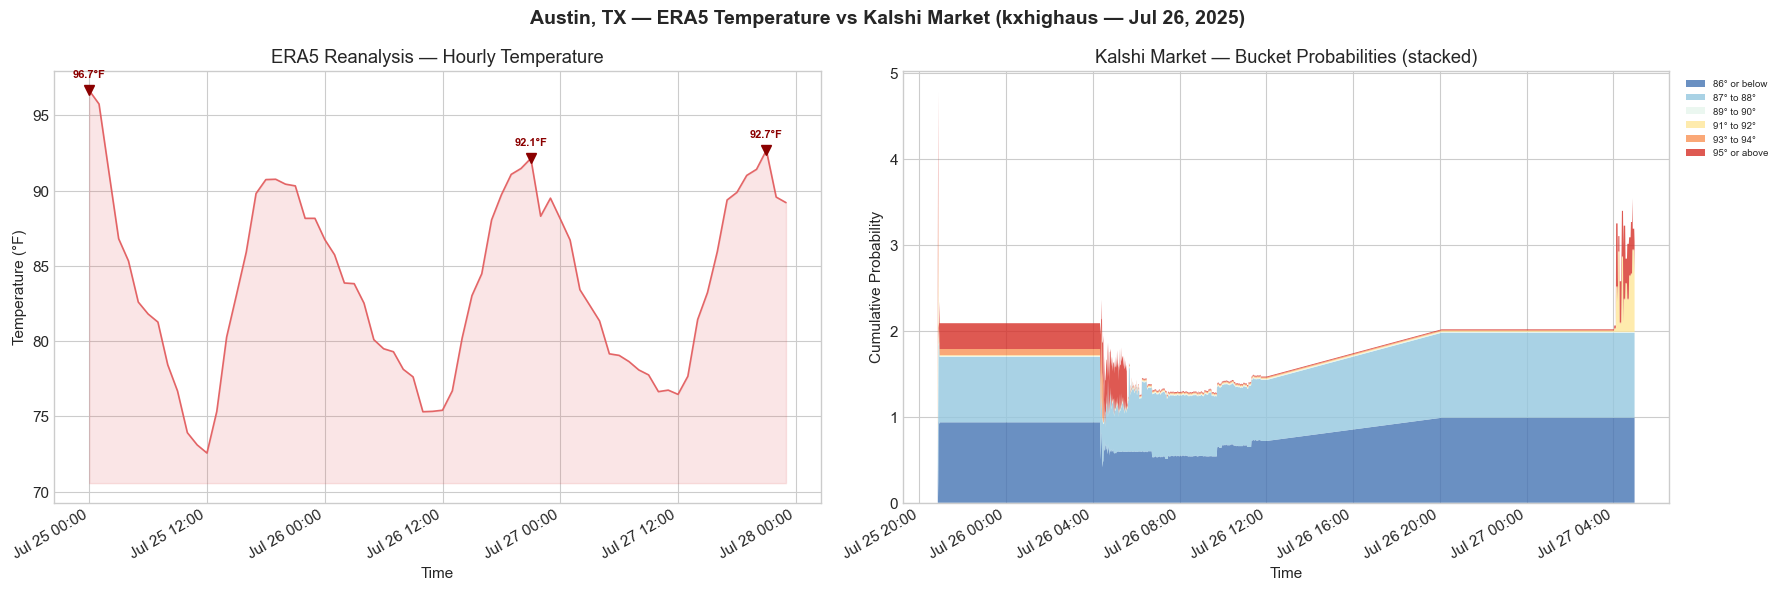

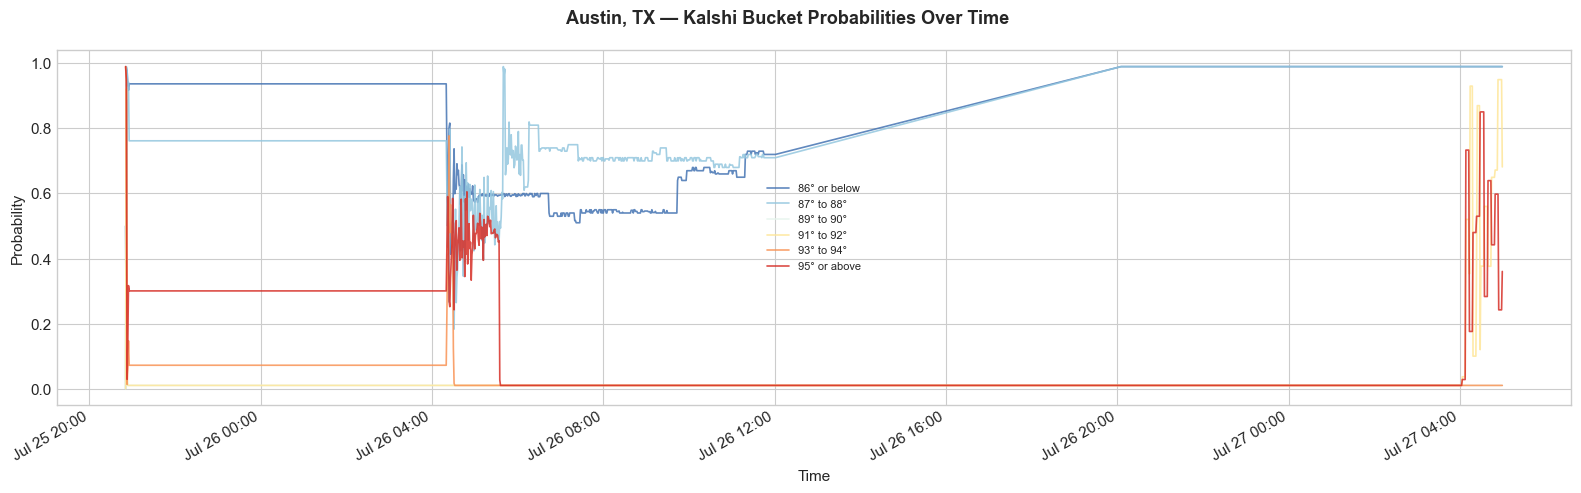

In [9]:
era_aus = load_era_temp('AUS_TEMP_ERA.csv')
kalshi_aus, buckets_aus = load_kalshi('kalshi-price-history-kxhighaus-25jul26-minute.csv')

print_temp_summary(era_aus, 'Austin, TX')
plot_temp_pair(era_aus, kalshi_aus, buckets_aus, 'Austin, TX', 'kxhighaus — Jul 26, 2025')

---
## 2. Chicago, IL — High Temperature, Jul 25–26, 2025

**Kalshi market:** "What will the high temperature be in Chicago on Jul 26?"  
**Buckets:** 82° or below, 83–84°, 85–86°, 87–88°, 89–90°, 91° or above

  Chicago, IL ERA5 Summary
  ————————————————————————————————————————
  Period:     2025-07-25 00:00:00 → 2025-07-27 23:00:00
  Data points: 72 hourly observations
  Jul 25: High=80.6°F  Low=75.7°F  Mean=78.2°F
  Jul 26: High=80.9°F  Low=72.8°F  Mean=74.9°F
  Jul 27: High=83.6°F  Low=74.2°F  Mean=78.3°F



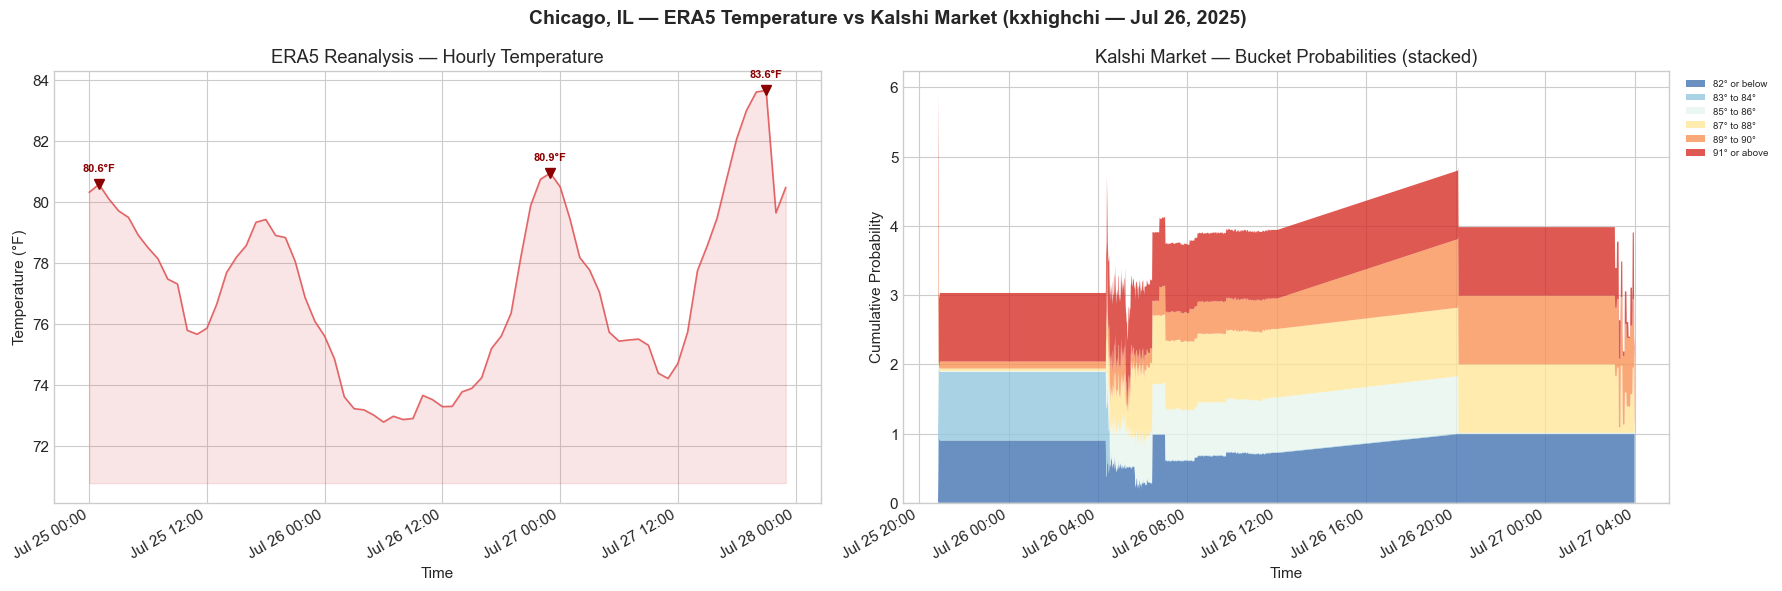

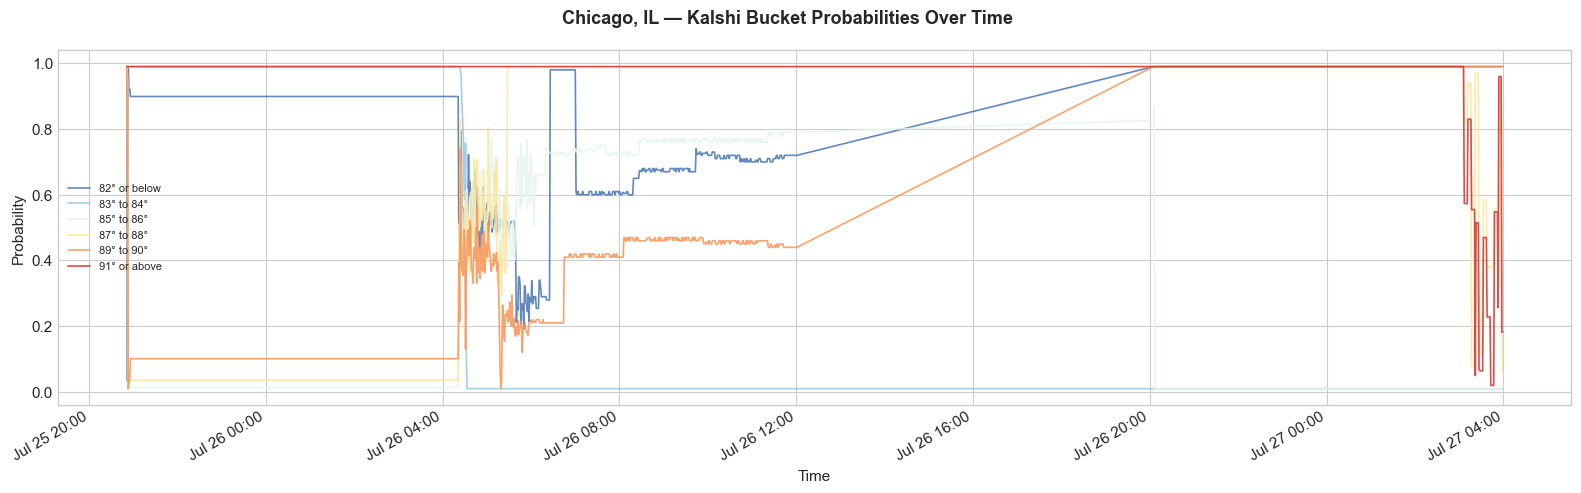

In [10]:
era_chi = load_era_temp('CHI_TEMP_ERA.csv')
kalshi_chi, buckets_chi = load_kalshi('kalshi-price-history-kxhighchi-25jul26-minute.csv')

print_temp_summary(era_chi, 'Chicago, IL')
plot_temp_pair(era_chi, kalshi_chi, buckets_chi, 'Chicago, IL', 'kxhighchi — Jul 26, 2025')

---
## 3. Houston, TX — High Temperature, Jul 25–26, 2025

**Kalshi market:** "What will the high temperature be in Houston on Jul 26?"  
**Buckets:** 85° or below, 86–87°, 88–89°, 90–91°, 92–93°, 94° or above

  Houston, TX ERA5 Summary
  ————————————————————————————————————————
  Period:     2025-07-25 00:00:00 → 2025-07-27 23:00:00
  Data points: 72 hourly observations
  Jul 25: High=91.7°F  Low=78.0°F  Mean=82.1°F
  Jul 26: High=88.5°F  Low=75.5°F  Mean=81.0°F
  Jul 27: High=89.6°F  Low=76.8°F  Mean=83.1°F



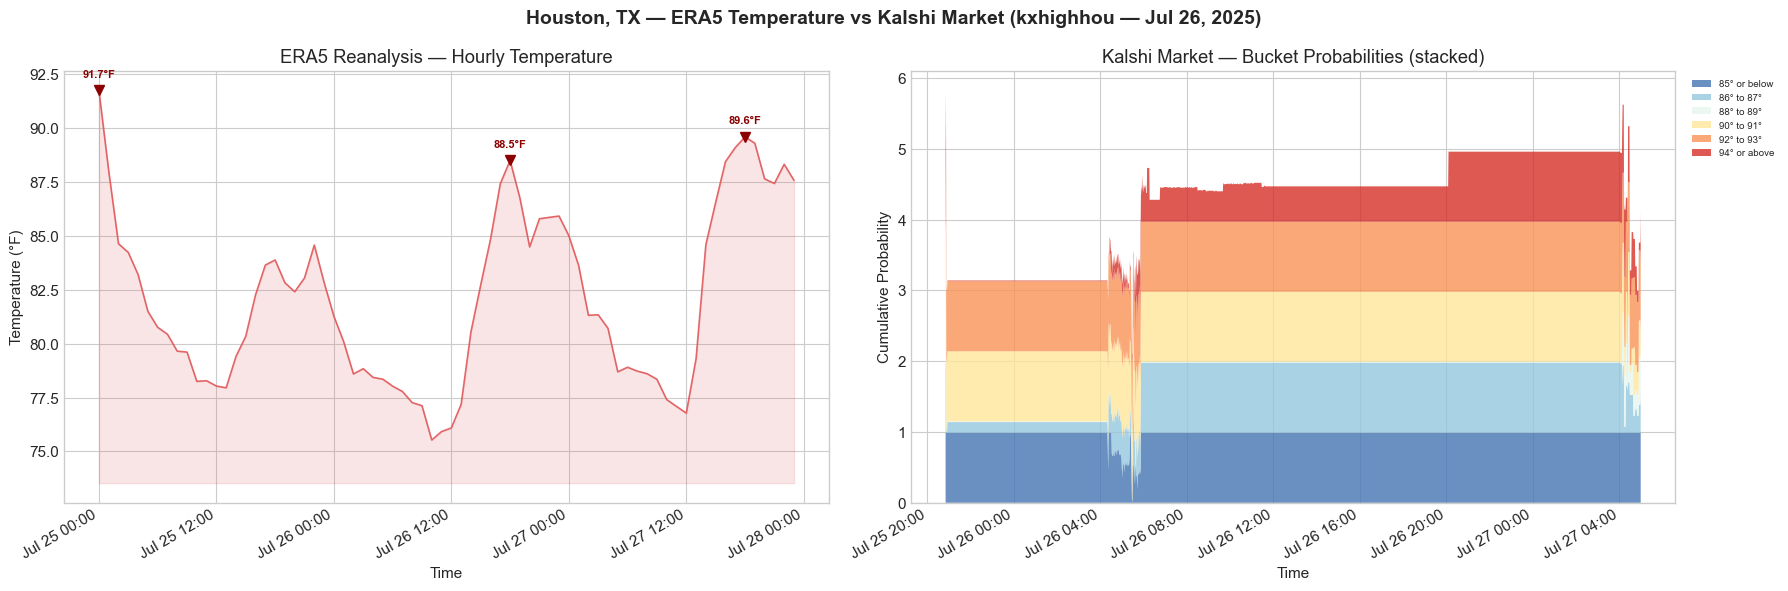

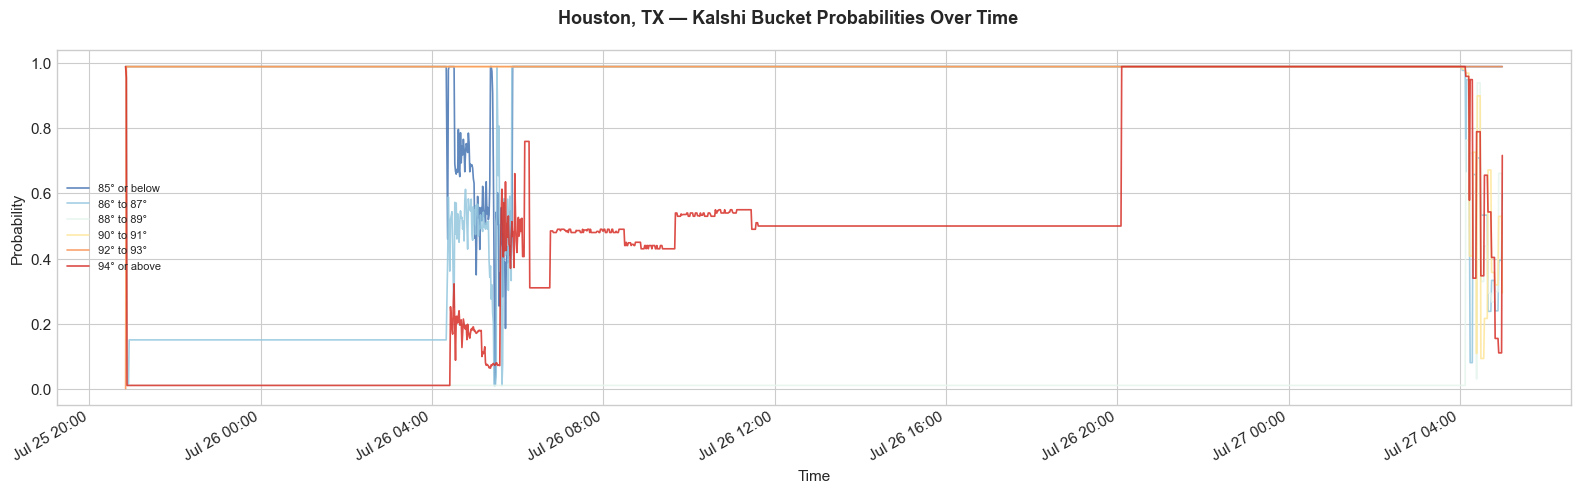

In [11]:
era_hou = load_era_temp('HOU_TEMP_ERA.csv')
kalshi_hou, buckets_hou = load_kalshi('kalshi-price-history-kxhighhou-25jul26-minute.csv')

print_temp_summary(era_hou, 'Houston, TX')
plot_temp_pair(era_hou, kalshi_hou, buckets_hou, 'Houston, TX', 'kxhighhou — Jul 26, 2025')

---
## 4. Los Angeles, CA — High Temperature, Dec 15, 2025

**Kalshi market:** "What will the high temperature be in LA on Dec 15?"  
**Buckets:** 64° or below, 65–66°, 67–68°, 69–70°, 71–72°, 73° or above

  Los Angeles, CA ERA5 Summary
  ————————————————————————————————————————
  Period:     2025-12-15 00:00:00 → 2025-12-16 23:00:00
  Data points: 48 hourly observations
  Dec 15: High=68.9°F  Low=51.5°F  Mean=58.5°F
  Dec 16: High=70.0°F  Low=50.8°F  Mean=58.0°F



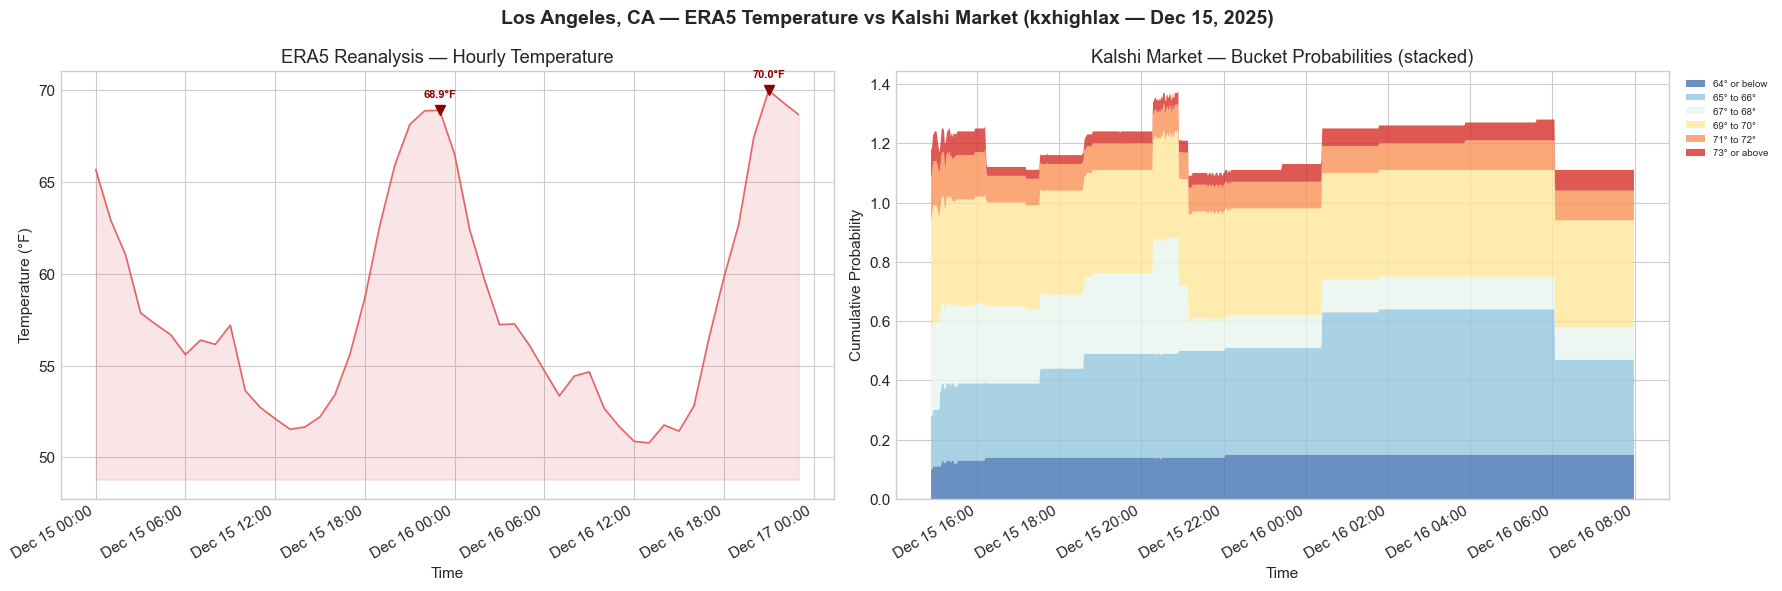

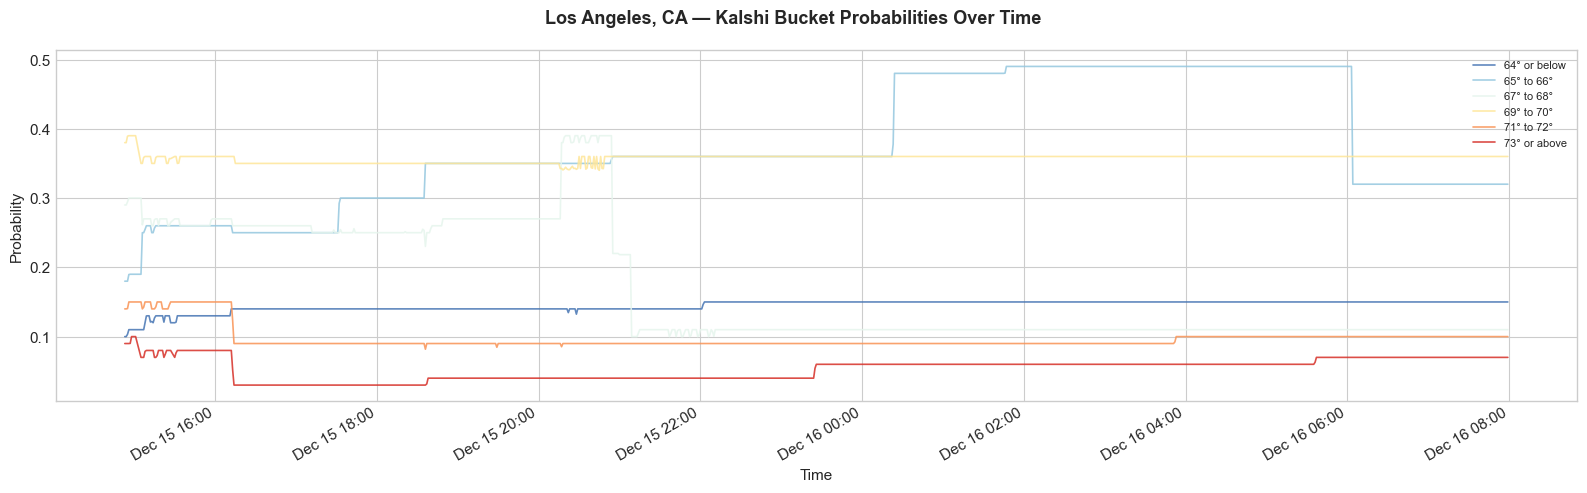

In [12]:
era_la = load_era_temp('LA_TEMP_ERA.csv')
kalshi_la, buckets_la = load_kalshi('kalshi-price-history-kxhighlax-25dec15-minute.csv')

print_temp_summary(era_la, 'Los Angeles, CA')
plot_temp_pair(era_la, kalshi_la, buckets_la, 'Los Angeles, CA', 'kxhighlax — Dec 15, 2025')

---
## 5. Miami, FL — High Temperature, Dec 15, 2025

**Kalshi market:** "What will the high temperature be in Miami on Dec 15?"  
**Buckets:** 70° or below, 71–72°, 73–74°, 75–76°, 77–78°, 79° or above

  Miami, FL ERA5 Summary
  ————————————————————————————————————————
  Period:     2025-12-15 00:00:00 → 2025-12-16 23:00:00
  Data points: 48 hourly observations
  Dec 15: High=74.0°F  Low=70.0°F  Mean=71.6°F
  Dec 16: High=72.7°F  Low=68.8°F  Mean=70.5°F



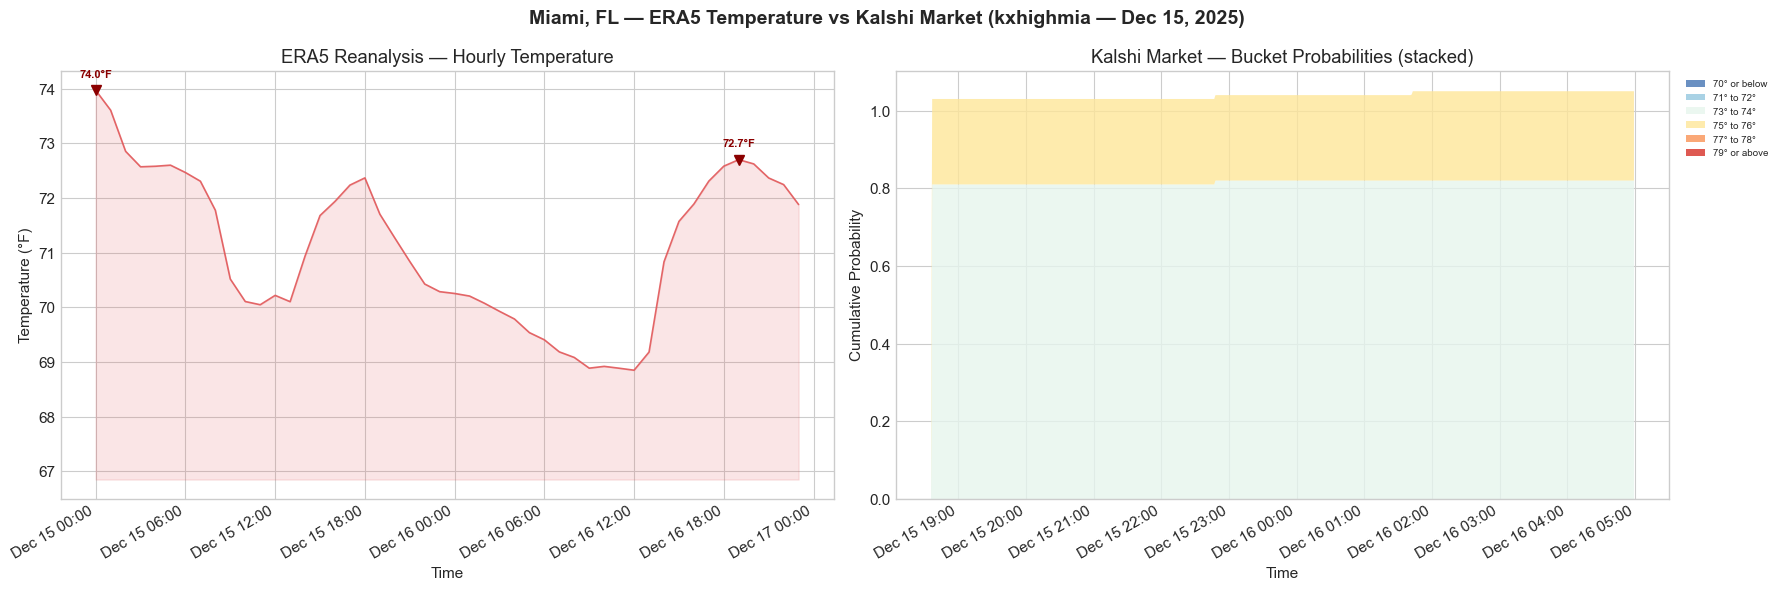

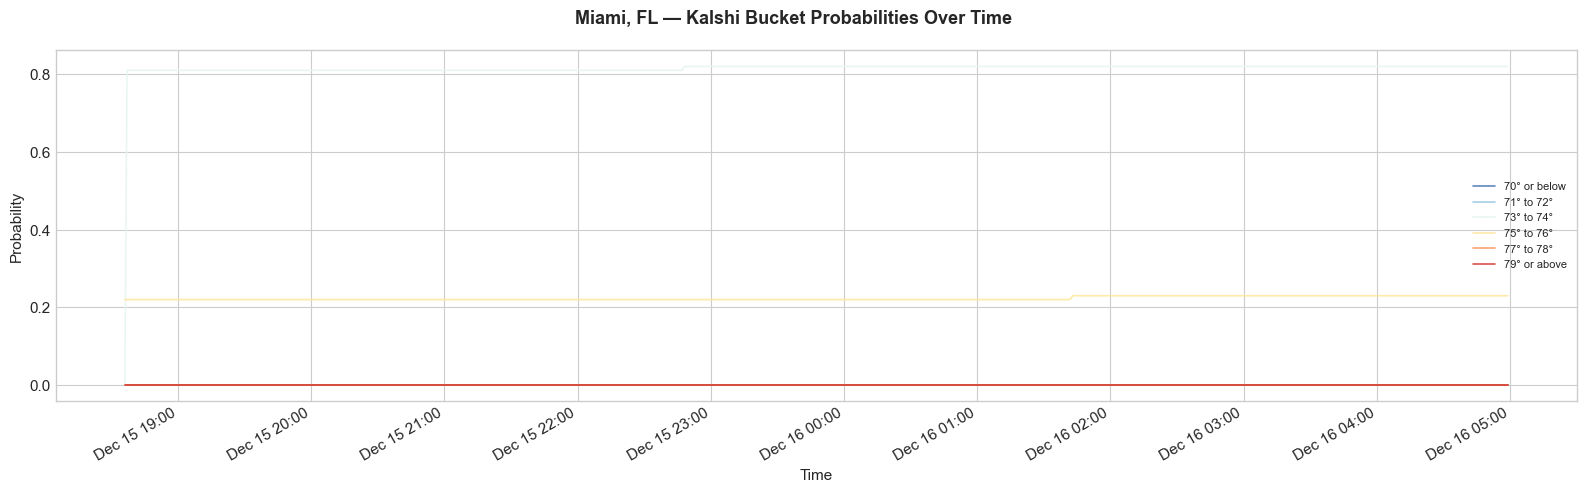

In [13]:
era_mia = load_era_temp('MIA_TEMP_ERA.csv')
kalshi_mia, buckets_mia = load_kalshi('kalshi-price-history-kxhighmia-25dec15-minute.csv')

print_temp_summary(era_mia, 'Miami, FL')
plot_temp_pair(era_mia, kalshi_mia, buckets_mia, 'Miami, FL', 'kxhighmia — Dec 15, 2025')

---
## 6. New York, NY — High Temperature, Dec 15, 2025

**Kalshi market:** "What will the high temperature be in NYC on Dec 15?"  
**Buckets:** 25° or below, 26–27°, 28–29°, 30–31°, 32–33°, 34° or above

  New York, NY ERA5 Summary
  ————————————————————————————————————————
  Period:     2025-12-15 00:00:00 → 2025-12-16 23:00:00
  Data points: 48 hourly observations
  Dec 15: High=28.0°F  Low=19.3°F  Mean=22.6°F
  Dec 16: High=30.7°F  Low=18.6°F  Mean=24.8°F



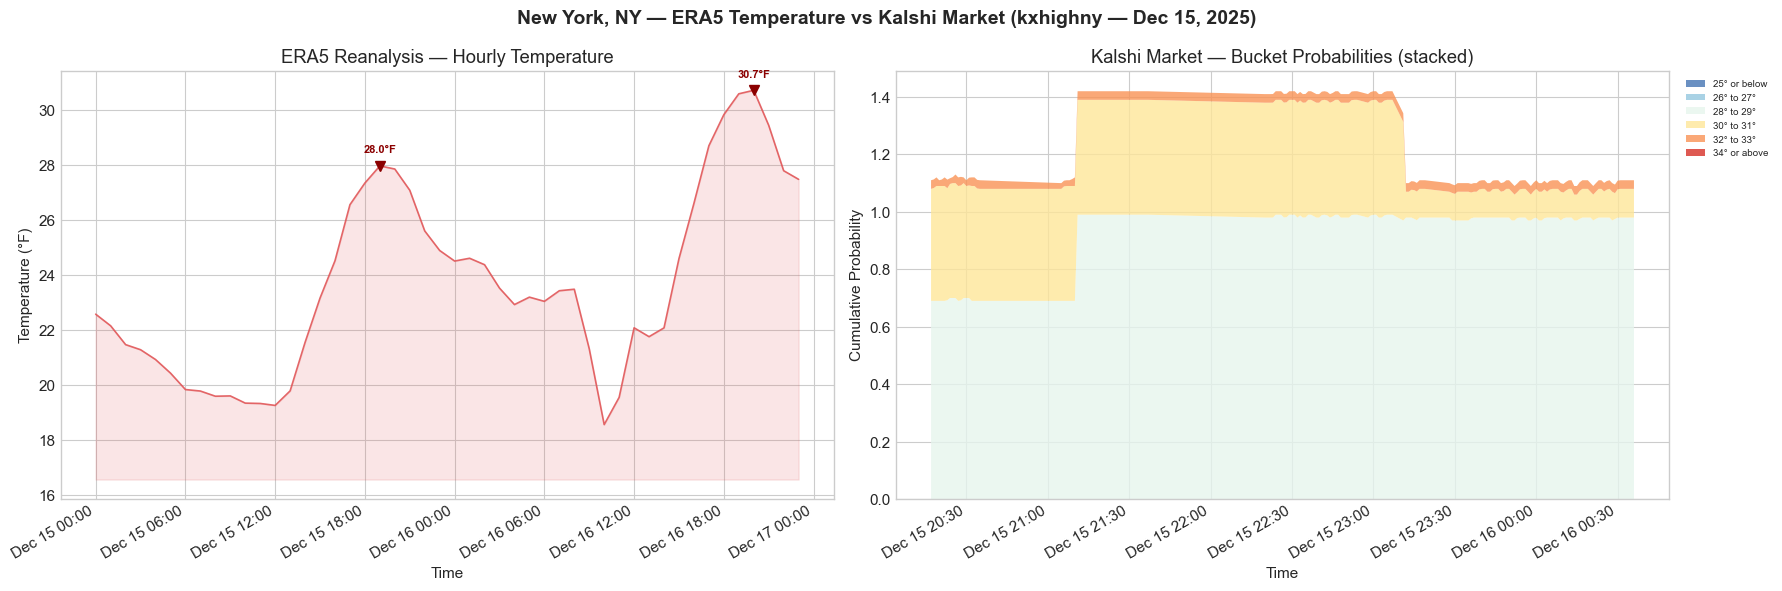

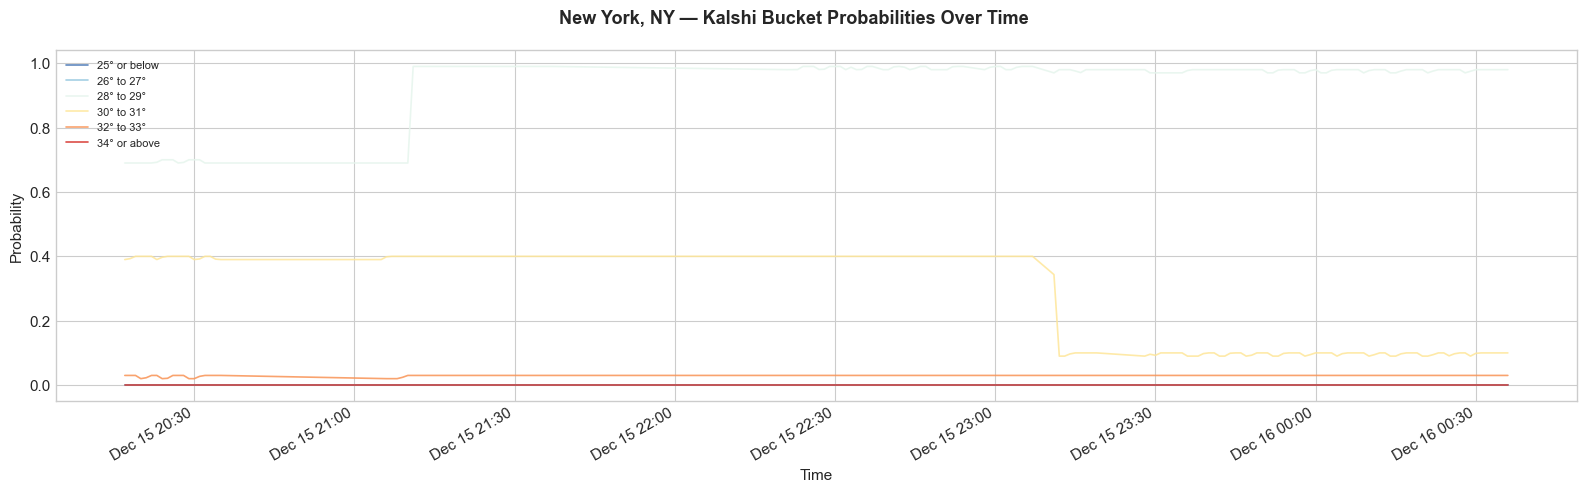

In [14]:
era_ny = load_era_temp('NY_TEMP_ERA.csv')
kalshi_ny, buckets_ny = load_kalshi('kalshi-price-history-kxhighny-25dec15-minute.csv')

print_temp_summary(era_ny, 'New York, NY')
plot_temp_pair(era_ny, kalshi_ny, buckets_ny, 'New York, NY', 'kxhighny — Dec 15, 2025')

---
## 7. Philadelphia, PA — ERA5 Temperature Only (No Kalshi Market)

Philadelphia has ERA5 reanalysis data for Jul 25–27, 2025 but no corresponding Kalshi event market.  
Included here for completeness.

  Philadelphia, PA ERA5 Summary
  ————————————————————————————————————————
  Period:     2025-07-25 00:00:00 → 2025-07-27 23:00:00
  Data points: 72 hourly observations
  Jul 25: High=96.0°F  Low=75.4°F  Mean=83.2°F
  Jul 26: High=85.9°F  Low=75.6°F  Mean=81.2°F
  Jul 27: High=85.8°F  Low=73.1°F  Mean=78.3°F



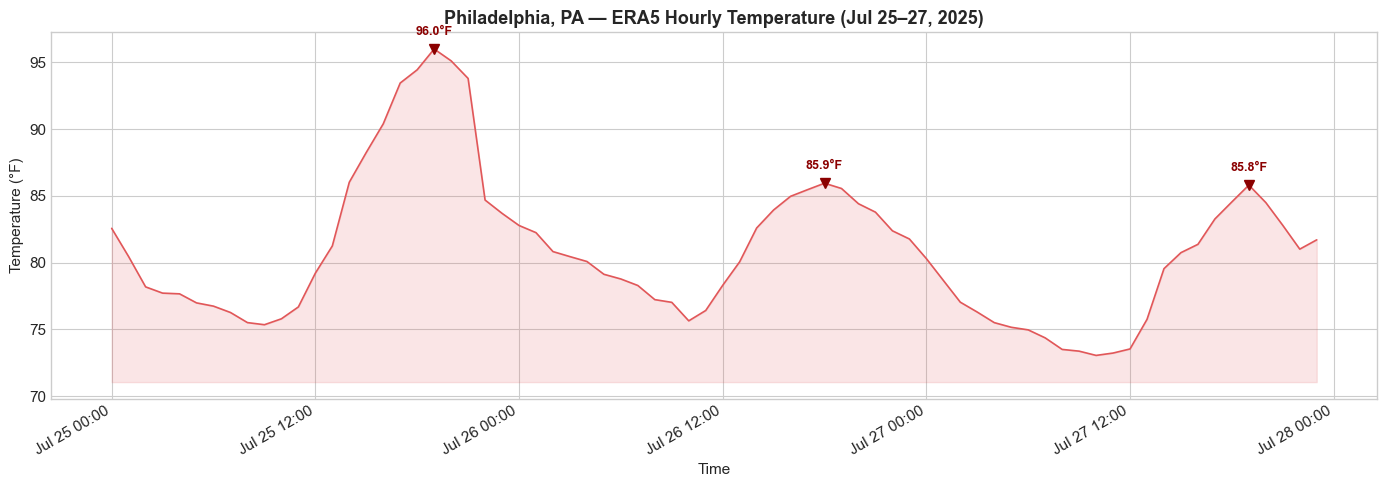

  Note: No Kalshi event market available for Philadelphia.


In [15]:
era_phil = load_era_temp('PHIL_TEMP_ERA.csv')
print_temp_summary(era_phil, 'Philadelphia, PA')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(era_phil['time'], era_phil['temperature_f'], color='#e15759', linewidth=1.2)
ax.fill_between(era_phil['time'], era_phil['temperature_f'].min() - 2, era_phil['temperature_f'],
                alpha=0.15, color='#e15759')

# Mark daily highs (using the helper to avoid pandas version issues)
highs, high_times = _get_daily_highs(era_phil)
for dt in highs:
    high = highs[dt]
    t = high_times[dt]
    if pd.notna(t) and pd.notna(high):
        ax.annotate(f'{high:.1f}°F', xy=(t, high), fontsize=9, fontweight='bold',
                     color='darkred', ha='center', va='bottom',
                     xytext=(0, 8), textcoords='offset points')
        ax.plot(t, high, 'v', color='darkred', markersize=7)

ax.set_ylabel('Temperature (°F)')
ax.set_xlabel('Time')
ax.set_title('Philadelphia, PA — ERA5 Hourly Temperature (Jul 25–27, 2025)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()
print('  Note: No Kalshi event market available for Philadelphia.')

---
## 8. NYC Monthly Snowfall — January 2026

**Kalshi market:** "How much total snow will NYC get in January 2026?"  
**Buckets:** Above 0.1", Above 3", Above 6", Above 10", Above 15", Above 20", Above 25"

  NYC Monthly Snow ERA5 Summary
  ————————————————————————————————————————
  Period:       2026-01-23 00:00:00 → 2026-01-30 23:00:00
  Data points:  192 hourly observations
  Total precip: 0.941 in
  Total snow:   0.000 in
  Snow hours:   0 / 192
  Temp range:   41.7°F – 64.7°F



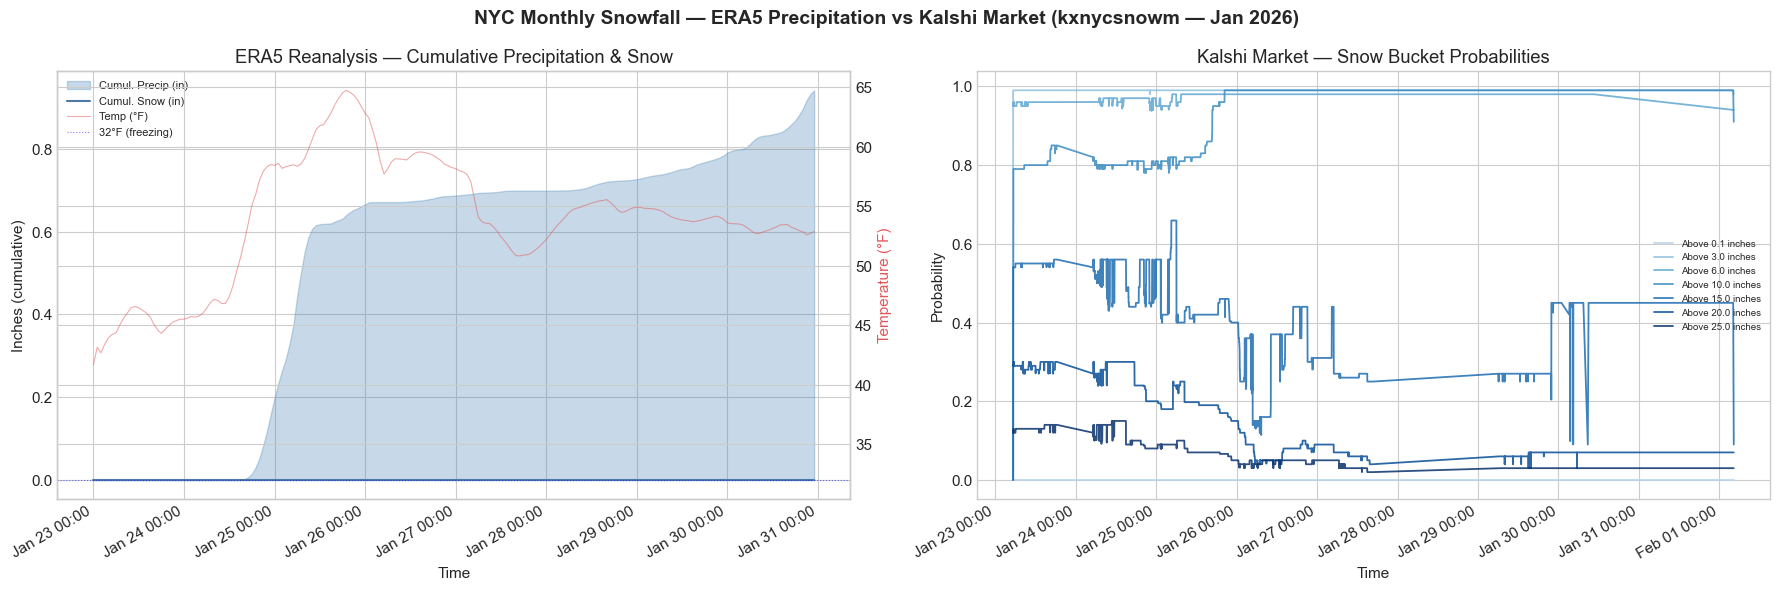

In [16]:
era_snow = load_era_snow('NY_SNOW_ERA.csv')
kalshi_snow, buckets_snow = load_kalshi('kalshi-price-history-kxnycsnowm-26jan-minute.csv')

print(f"  NYC Monthly Snow ERA5 Summary")
print(f"  {'—'*40}")
print(f"  Period:       {era_snow['time'].min()} → {era_snow['time'].max()}")
print(f"  Data points:  {len(era_snow)} hourly observations")
print(f"  Total precip: {era_snow['precipitation_inches'].sum():.3f} in")
print(f"  Total snow:   {era_snow['snow_inches'].sum():.3f} in")
print(f"  Snow hours:   {era_snow['is_snow'].sum()} / {len(era_snow)}")
print(f"  Temp range:   {(era_snow['temperature_c']*9/5+32).min():.1f}°F – {(era_snow['temperature_c']*9/5+32).max():.1f}°F")
print()

plot_snow_pair(era_snow, kalshi_snow, buckets_snow, 'NYC Monthly Snowfall', 'kxnycsnowm — Jan 2026')

---
## 9. NYC Snowstorm — January 2026

**Kalshi market:** "How much snow will the NYC snowstorm on Jan 26 produce?"  
**Buckets:** Above 2", Above 4", Above 6", Above 8", Above 10", Above 12", Above 15", Above 18", Above 20", Above 24"

  NYC Snowstorm ERA5 Summary
  ————————————————————————————————————————
  Period:       2026-01-23 00:00:00 → 2026-01-26 23:00:00
  Data points:  96 hourly observations
  Total precip: 0.686 in
  Total snow:   0.000 in
  Snow hours:   0 / 96
  Temp range:   41.7°F – 64.7°F



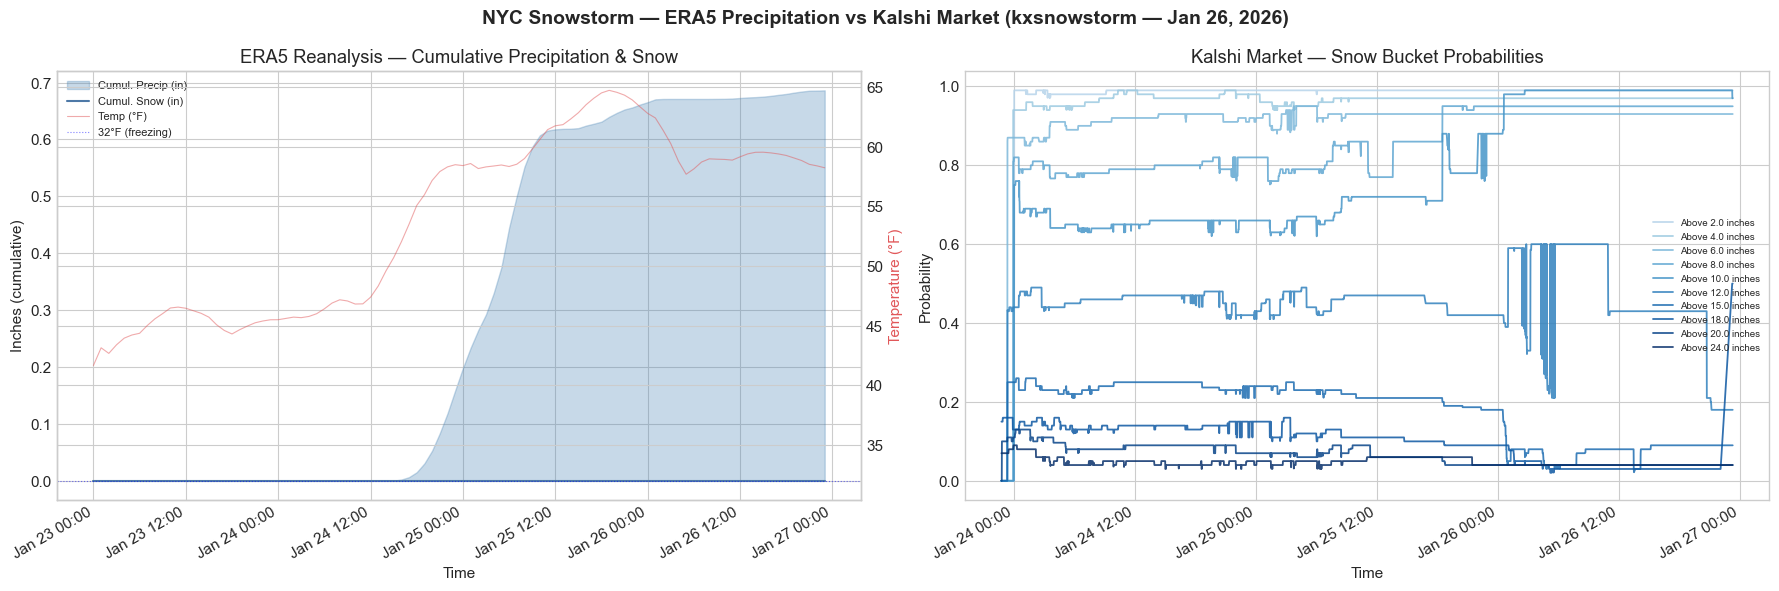

In [17]:
era_ssnow = load_era_snow('NY_SSNOW_ERA.csv')
kalshi_ssnow, buckets_ssnow = load_kalshi('kalshi-price-history-kxsnowstorm-26jannyc-minute.csv')

print(f"  NYC Snowstorm ERA5 Summary")
print(f"  {'—'*40}")
print(f"  Period:       {era_ssnow['time'].min()} → {era_ssnow['time'].max()}")
print(f"  Data points:  {len(era_ssnow)} hourly observations")
print(f"  Total precip: {era_ssnow['precipitation_inches'].sum():.3f} in")
print(f"  Total snow:   {era_ssnow['snow_inches'].sum():.3f} in")
print(f"  Snow hours:   {era_ssnow['is_snow'].sum()} / {len(era_ssnow)}")
print(f"  Temp range:   {(era_ssnow['temperature_c']*9/5+32).min():.1f}°F – {(era_ssnow['temperature_c']*9/5+32).max():.1f}°F")
print()

plot_snow_pair(era_ssnow, kalshi_ssnow, buckets_ssnow, 'NYC Snowstorm', 'kxsnowstorm — Jan 26, 2026')

---
## All-City Temperature Comparison

Overlay all six cities' temperature profiles on one chart to see relative conditions.

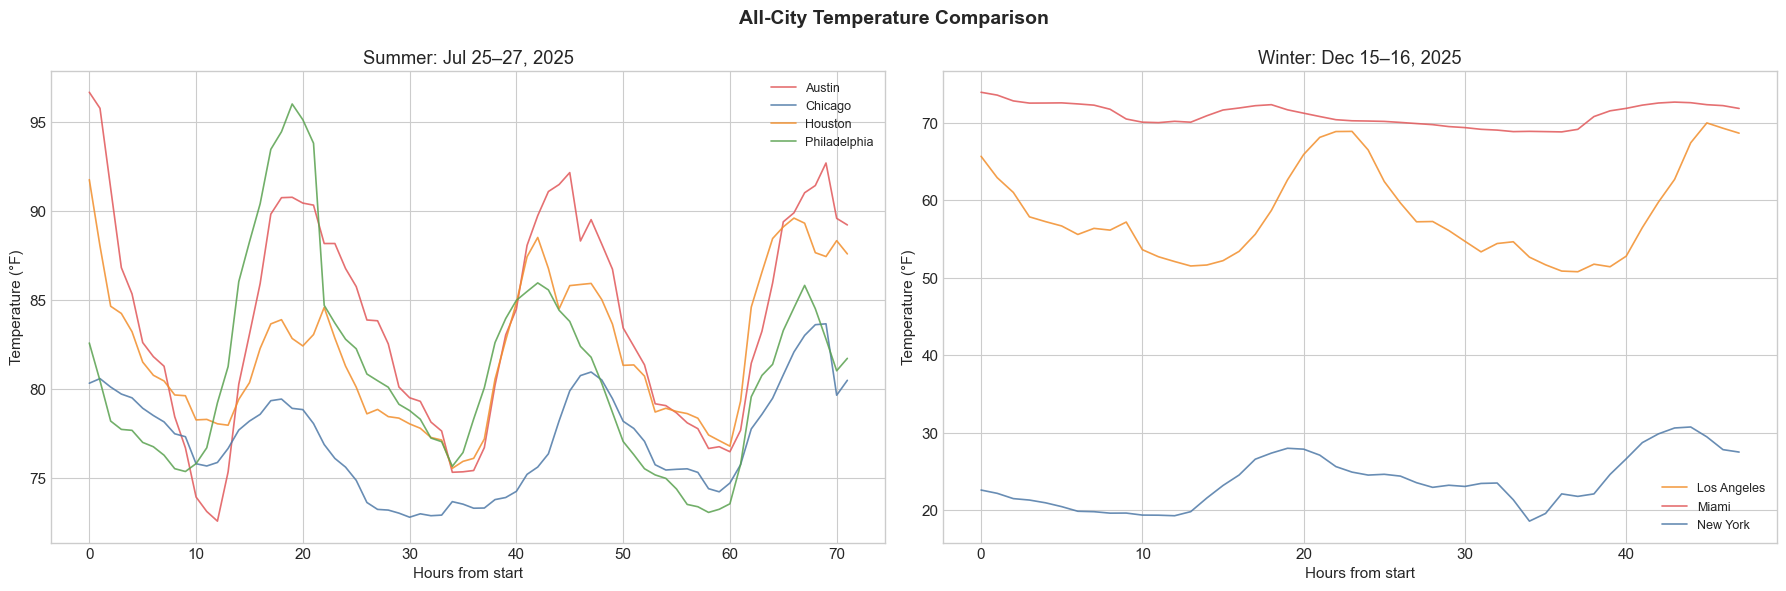

In [18]:
# Group by event date for cleaner comparison
summer_cities = [
    ('Austin', era_aus, '#e15759'),
    ('Chicago', era_chi, '#4e79a7'),
    ('Houston', era_hou, '#f28e2b'),
    ('Philadelphia', era_phil, '#59a14f'),
]

winter_cities = [
    ('Los Angeles', era_la, '#f28e2b'),
    ('Miami', era_mia, '#e15759'),
    ('New York', era_ny, '#4e79a7'),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('All-City Temperature Comparison', fontsize=14, fontweight='bold')

# Summer cities (Jul 25-27, 2025)
for name, df, color in summer_cities:
    # Normalize to hours from start for overlay
    hours = (df['time'] - df['time'].min()).dt.total_seconds() / 3600
    ax1.plot(hours, df['temperature_f'], label=name, color=color, linewidth=1.2, alpha=0.85)
ax1.set_xlabel('Hours from start')
ax1.set_ylabel('Temperature (°F)')
ax1.set_title('Summer: Jul 25–27, 2025')
ax1.legend(fontsize=9)

# Winter cities (Dec 15-16, 2025)
for name, df, color in winter_cities:
    hours = (df['time'] - df['time'].min()).dt.total_seconds() / 3600
    ax2.plot(hours, df['temperature_f'], label=name, color=color, linewidth=1.2, alpha=0.85)
ax2.set_xlabel('Hours from start')
ax2.set_ylabel('Temperature (°F)')
ax2.set_title('Winter: Dec 15–16, 2025')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Summary

This notebook visualized 9 ERA5 weather datasets alongside their corresponding Kalshi event markets:

- **6 temperature markets** across Austin, Chicago, Houston, LA, Miami, and NYC — showing how Kalshi bucket probabilities shift in real time as the actual temperature evolves throughout the day.
- **1 standalone temperature** (Philadelphia) — ERA5 data only, no Kalshi market.
- **2 snow markets** (NYC January 2026) — cumulative precipitation vs Kalshi's snowfall threshold probabilities.

Key observations:
- Kalshi markets react quickly to developing weather conditions, with probability mass shifting between buckets as temperatures rise and fall.
- The stacked area charts show total probability allocation across buckets at any point in time.
- Snow markets show a clear step-function behavior as accumulation thresholds are crossed.